In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# Load datase

ds = load_dataset("ninaa510/diagnosis-text")

Generating test split: 100%|██████████| 4262/4262 [00:00<00:00, 168331.42 examples/s]


In [4]:
ds.column_names

{'train': ['label', 'sentence1'], 'test': ['label', 'sentence1']}

Class distribution:
 label
Allergic sinusitis         1331
Anaphylaxis                1331
Chagas                     1331
HIV (initial infection)    1331
Influenza                  1331
Localized edema            1331
SLE                        1331
Sarcoidosis                1331
Tuberculosis               1331
Whooping cough             1331
Name: count, dtype: int64


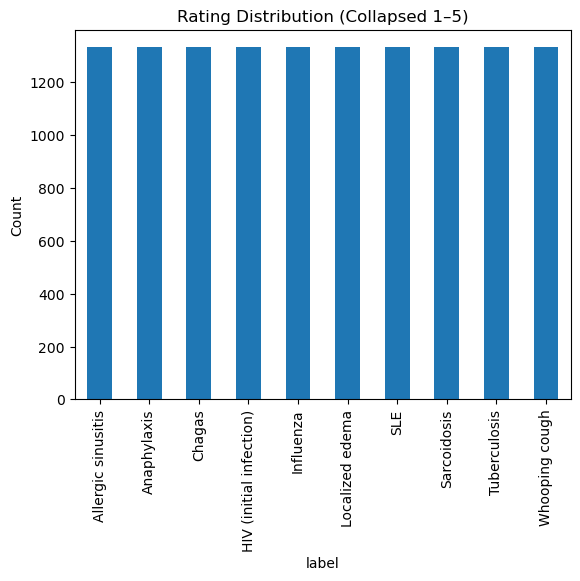


Balanced class distribution:
 label
Allergic sinusitis         1331
Anaphylaxis                1331
Chagas                     1331
HIV (initial infection)    1331
Influenza                  1331
Localized edema            1331
SLE                        1331
Sarcoidosis                1331
Tuberculosis               1331
Whooping cough             1331
Name: count, dtype: int64


/var/folders/gj/bbgjz4_x5ybc58ms5zv9p8sr0000gp/T/ipykernel_55587/66532760.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("label", group_keys=False).apply(


In [6]:
# ds = load_dataset("Mouwiya/drug-reviews")

# Convert to Pandas for exploration (train split only as example)
df = ds["train"].to_pandas()


# Check distribution (imbalance)
rating_counts = df["label"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

# visualize the distribution
rating_counts.plot(kind="bar", title="Rating Distribution (Collapsed 1–5)")
plt.xlabel("label")
plt.ylabel("Count")
plt.show()

# Balance dataset (undersample the majority class for demonstration)
min_count = rating_counts.min()
balanced_df = df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min_count, random_state=42)
)

print("\nBalanced class distribution:\n", balanced_df["label"].value_counts())

# This seems to be a perfect dataset!! 

In [10]:
# save the balanced dataset to you current directory
df.to_csv("diagnosis_text.csv")

In [8]:
#from transformers import pipeline

#classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

#text = "This drug really helped with my pain but caused nausea."
#candidate_labels = ["very negative", "negative", "neutral", "positive", "very positive"]

#result = classifier(text, candidate_labels)
#print(result)